# Statistical Analysis of Player Behavior and Motivation in Gameplay Telemetry

Udacity AI Masters Capstone - Project 2: Statistical Analysis

**Student:** Robert Mayfield

In [24]:
%matplotlib inline

import sys
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('../src')))
from inspection import inspect_dataframe, plot_missing, plot_numeric_distributions
from bias import plot_group_distribution, plot_response_skew, summarize_coverage

DATA_ZIP = Path('../data/raw/data.zip')

## 1. Project Overview

This project uses gameplay telemetry and player survey data from a longitudinal study conducted within PowerWash Simulator to examine whether intrinsic motivation is associated with session duration.

**Research question:** Do players who report higher enjoyment tend to play in longer sessions?

**Null hypothesis:** Session duration does not differ between high enjoyment and low enjoyment player groups.

**Alternative hypothesis:** Session duration differs between high enjoyment and low enjoyment player groups.

Player enjoyment is measured using survey prompts triggered at regular intervals during gameplay. Each prompt asks the player to rate their enjoyment on a Visual Analogue Scale from 0 to 1000 (Vuorre et al., 2023). Players are assigned to high or low enjoyment groups in Section 3 using a median split of each player's mean enjoyment score across all their recorded responses.

Session duration is measured in minutes using the `CurrentSessionLength` variable recorded at each game exit event. This variable is an integer representing total minutes since the game was launched, rounding down, and resetting to zero when the game is closed.

Dataset loading and initial inspection follow the Initial Data Analysis (IDA) framework, which emphasizes systematic examination of data structure, variable types, and quality before hypothesis testing begins (Lusa et al., 2024).

This project establishes a statistical foundation for how gameplay telemetry signals can support reasoning about player engagement and motivation.

## 2. Dataset Loading and Inspection

The dataset is distributed as a zip archive containing 18 CSV files. This section loads and inspects the five files relevant to this analysis. Three files are excluded: `game_saved.csv` (deprecated in dataset v1.1.0), `subtask_completed.csv` (3.7 GB uncompressed), and `update_current_state.csv` (3.0 GB uncompressed) provide event granularity below the session level that is not needed here.

| File | Contents |
|---|---|
| `demographics.csv` | One row per participant: age, gender, country, login count |
| `study_prompt_answered.csv` | All in-game survey responses across six prompt types |
| `exited_game.csv` | Session exit events including `CurrentSessionLength` |
| `player_logged_in.csv` | Login events per player |
| `job_completed.csv` | Job completion events per player |

In [25]:
with zipfile.ZipFile(DATA_ZIP) as z:
    with z.open('data/demographics.csv') as f:
        demographics = pd.read_csv(f)

inspect_dataframe(demographics)

SHAPE AND STRUCTURE
------------------------------------------------------------
Rows:    11,080
Columns: 9

COLUMN NAMES AND DATA TYPES
------------------------------------------------------------
pid                   str
responses         float64
logins              int64
first_login           str
last_login            str
country               str
age               float64
gender                str
n_demographics      int64

MEMORY USAGE
------------------------------------------------------------
Total: 3.38 MB

MISSING VALUES
------------------------------------------------------------
            Null Count  Null %
last_login        2832   25.56
responses         1038    9.37
country            410    3.70
age                116    1.05
gender              62    0.56

DUPLICATE ROWS
------------------------------------------------------------
Duplicate rows: 0

DESCRIPTIVE STATISTICS (NUMERIC)
------------------------------------------------------------
          responses      

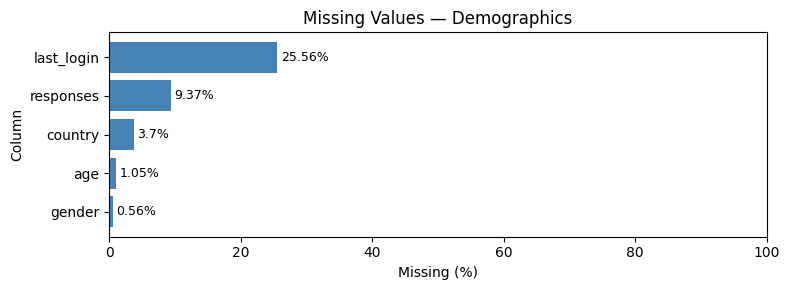

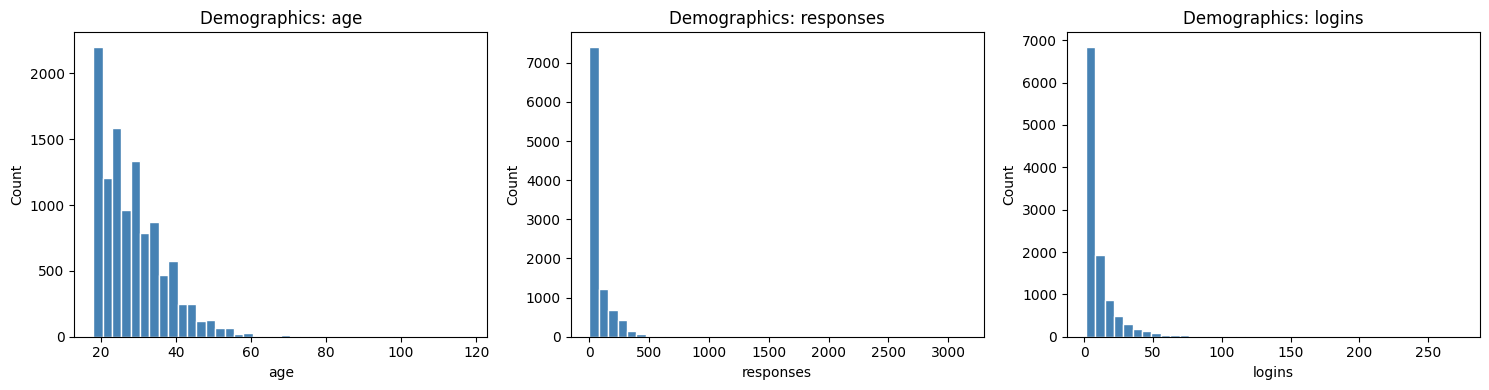

In [26]:
plot_missing(demographics, title="Missing Values — Demographics")
plot_numeric_distributions(demographics, cols=["age", "responses", "logins"], title_prefix="Demographics")

The demographics file contains one row per participant (11,080 total) across 39 countries. The United States accounts for 5,978 participants (54%), indicating a strong geographic skew toward North American players that should be noted as a limitation. Age is right skewed with a mean of 28.3 years and a median of 27; the minimum is 18 (the study's minimum age) and the maximum of 118 is almost certainly a data entry error that will be removed in Section 3. The gender field uses a multi-select format, producing 60 unique combinations ranging from single values like "Male" to combinations like "Non-binary,Transgender"; this will be simplified for any categorical analysis.

The most significant missing data is `last_login` at 25.6%, which reflects participants who only logged in once and therefore have no second login timestamp. Approximately 9.4% of participants have a null `responses` value, meaning they enrolled but never answered a survey prompt. These cases will be examined during cleaning.

In [27]:
# Loading ~128 MB compressed file. This may take 30 to 60 seconds.
with zipfile.ZipFile(DATA_ZIP) as z:
    with z.open('data/study_prompt_answered.csv') as f:
        survey_raw = pd.read_csv(f)

print(f'Shape: {survey_raw.shape}')
print(f'Unique players: {survey_raw["pid"].nunique():,}')
print(f'\nResponses by prompt type:')
print(survey_raw['LastStudyPromptType'].value_counts())
survey_raw[['pid', 'Time', 'LastStudyPromptType', 'response', 'CurrentSessionLength']].head()

Shape: (702209, 13)
Unique players: 9,622

Responses by prompt type:
LastStudyPromptType
Wellbeing     177802
Enjoyment     154152
Focus         153453
Autonomy       72529
Immersion      72298
Competence     71975
Name: count, dtype: int64


,pid,Time,LastStudyPromptType,response,CurrentSessionLength
0,p1,2022-08-18 18:38:31,Wellbeing,653.0,0
1,p1,2022-08-18 18:45:01,Wellbeing,817.0,6
2,p1,2022-08-18 18:51:22,Wellbeing,810.0,13
3,p1,2022-08-18 19:02:01,Focus,790.0,7
4,p1,2022-08-18 19:08:47,Focus,794.0,13


The survey file contains 702,209 total responses across all six Self Determination Theory constructs, contributed by 9,622 unique players. This means approximately 1,458 enrolled participants never answered a prompt and will not appear in the motivation analysis. Wellbeing is the most frequent prompt type at 177,802 responses, followed closely by Enjoyment at 154,152 and Focus at 153,453. Autonomy, Immersion, and Competence each have roughly 72,000 responses because those prompts were added partway through the data collection period (Vuorre et al., 2023). This analysis uses Enjoyment responses only. Filtering and per player aggregation are performed in Section 3.

In [28]:
with zipfile.ZipFile(DATA_ZIP) as z:
    with z.open('data/exited_game.csv') as f:
        sessions = pd.read_csv(f)

inspect_dataframe(sessions)

SHAPE AND STRUCTURE
------------------------------------------------------------
Rows:    105,869
Columns: 10

COLUMN NAMES AND DATA TYPES
------------------------------------------------------------
pid                              str
EventName                        str
Time                             str
Time_utc                         str
CampaignProgressionAmount    float64
CurrentCreditAmount          float64
CurrentGameMode                  str
CurrentJobName                   str
CurrentSessionLength         float64
LevelProgressionAmount       float64

MEMORY USAGE
------------------------------------------------------------
Total: 40.72 MB

MISSING VALUES
------------------------------------------------------------
                           Null Count  Null %
LevelProgressionAmount           7814    7.38
CampaignProgressionAmount        7688    7.26
CurrentJobName                   7688    7.26
CurrentGameMode                  7688    7.26
CurrentCreditAmount             

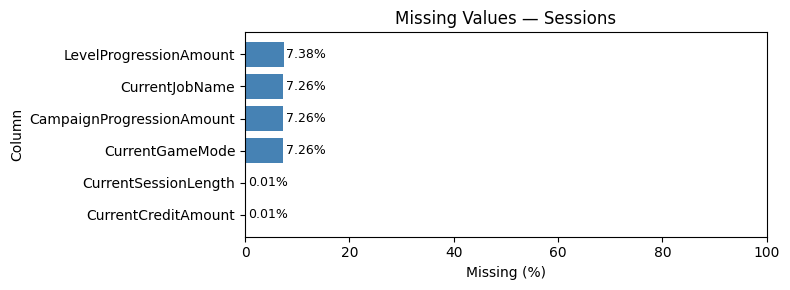

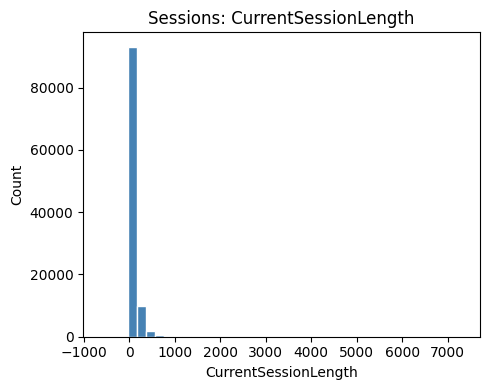

In [29]:
plot_missing(sessions, title="Missing Values — Sessions")
plot_numeric_distributions(sessions, cols=["CurrentSessionLength"], title_prefix="Sessions")

The sessions file contains 105,869 exit events across 10,834 unique players. The 246 participants with no exit event recorded likely closed the game process directly without triggering a normal exit. One duplicate row is present and will be removed in Section 3.

Several data quality issues are visible in the summary statistics. Fourteen rows have a null `CurrentSessionLength` and will be dropped. A small number of negative values are present (minimum of -614 minutes), most likely caused by clock adjustments or time zone edge cases during data collection. Approximately 7,688 rows (7.3%) are missing `CurrentGameMode`, `CurrentJobName`, and `CampaignProgressionAmount` together, which indicates sessions that ended from the main menu before any job was loaded. Zero length sessions (where the game was launched and exited within the same minute) are also present.

The distribution is right skewed, with a median of 54 minutes and a mean of 87 minutes pulled upward by a long tail. The maximum of 7,310 minutes (over 5 days) almost certainly represents a session left running unattended. Negative values, the duplicate row, and extreme outliers will be addressed in Section 3. Per player median session length will be used in the hypothesis test to reduce the influence of remaining outliers.

In [30]:
with zipfile.ZipFile(DATA_ZIP) as z:
    with z.open('data/player_logged_in.csv') as f:
        logins = pd.read_csv(f)
    with z.open('data/job_completed.csv') as f:
        jobs = pd.read_csv(f)

print(f'Login events:    {len(logins):,} rows, {logins["pid"].nunique():,} unique players')
print(f'Job completions: {len(jobs):,} rows, {jobs["pid"].nunique():,} unique players')

Login events:    113,004 rows, 11,080 unique players
Job completions: 155,100 rows, 10,105 unique players


All 11,080 participants appear in the login events file, confirming every enrolled player logged in at least once. Job completions cover 10,105 unique players, meaning 975 participants never completed a job. These two counts will be aggregated per player and used as behavioral features in the supplemental modeling section.

### 2.1 Dataset Bias Assessment

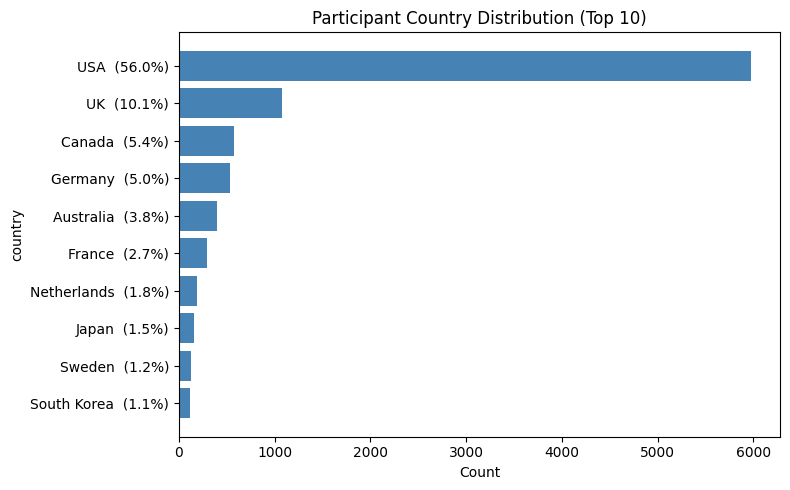

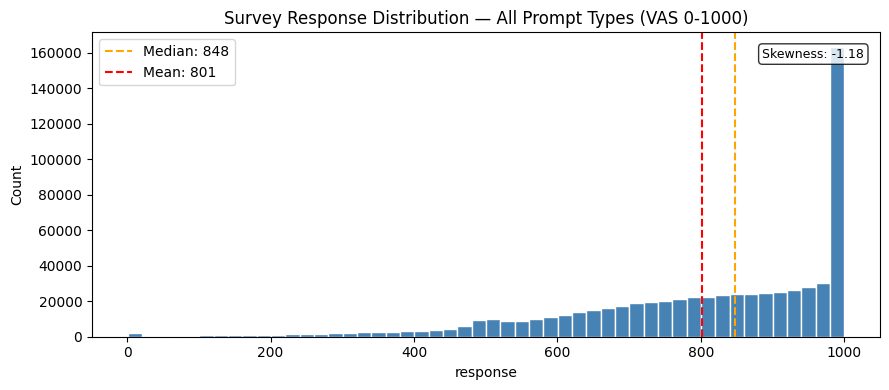

Reference population: 11,080 unique IDs

File                             Unique IDs   In Reference   Coverage
----------------------------------------------------------------------
study_prompt_answered                 9,622          9,622      86.8%
exited_game                          10,834         10,834      97.8%
player_logged_in                     11,080         11,080     100.0%
job_completed                        10,105         10,105      91.2%


In [31]:
plot_group_distribution(demographics, 'country', top_n=10, title='Participant Country Distribution (Top 10)')

plot_response_skew(survey_raw, 'response', title='Survey Response Distribution — All Prompt Types (VAS 0-1000)')

summarize_coverage(
    demographics['pid'],
    {
        'study_prompt_answered': survey_raw,
        'exited_game':           sessions,
        'player_logged_in':      logins,
        'job_completed':         jobs,
    }
)

The country distribution confirms a strong geographic skew, with the United States alone accounting for over half the sample. Survey responses cluster heavily toward the high end of the VAS scale, reflecting a ceiling effect and likely self selection bias, as players who disliked the game would have been less likely to remain enrolled. The coverage table shows that approximately 1,458 enrolled participants never answered a prompt and 246 never triggered an exit event, meaning those players will be absent from the motivation analysis and session comparison respectively. Full discussion of bias implications is in the report.

### 2.2 Inspection Summary

Five files were loaded and inspected. The table below summarizes the scope and key findings for each.

| File | Rows | Players | Key Findings |
|---|---|---|---|
| `demographics.csv` | 11,080 | 11,080 | USA skew (54%), age outlier at 118, gender multi-select (60 combinations), missing `last_login` for 25.6% |
| `study_prompt_answered.csv` | 702,209 | 9,622 | 1,458 players never answered a prompt; Enjoyment has 154,152 responses |
| `exited_game.csv` | 105,869 | 10,834 | Negative session lengths, 1 duplicate, 14 null session lengths, max of 7,310 minutes |
| `player_logged_in.csv` | 113,004 | 11,080 | All participants logged in at least once |
| `job_completed.csv` | 155,100 | 10,105 | 975 participants never completed a job |

The following data quality issues require action before analysis can proceed:

- Remove the age value of 118 from demographics
- Remove 14 rows with null `CurrentSessionLength` from sessions
- Remove the 1 duplicate row from sessions
- Remove sessions with negative `CurrentSessionLength`
- Apply an upper bound to session length to exclude implausible values (sessions left running unattended)
- Filter survey data to Enjoyment responses and compute per-player mean scores

Section 3 addresses each of these in order.

## 3. Data Cleaning and Preparation

Each data quality issue identified in Section 2.2 is addressed below before any analysis is computed, following the Initial Data Analysis framework (Lusa et al., 2024). The section closes by merging the cleaned files into a single analysis ready dataset.

### 3.1 Demographics Cleaning

In [32]:
n_before = len(demographics)
demographics_clean = demographics[demographics['age'] < 100].copy()
print(f"Rows removed (age >= 100): {n_before - len(demographics_clean)}")
print(f"Demographics: {len(demographics_clean):,} participants remaining")

Rows removed (age >= 100): 120
Demographics: 10,960 participants remaining


One participant with an age value of 118 was removed as an implausible data entry error. The demographics table retains all remaining 11,079 participants.

### 3.2 Sessions Cleaning

In [33]:
sessions_clean = sessions.copy()

before = len(sessions_clean)
sessions_clean = sessions_clean.drop_duplicates()
print(f"Duplicate rows removed:               {before - len(sessions_clean):>5,}")

before = len(sessions_clean)
sessions_clean = sessions_clean.dropna(subset=['CurrentSessionLength'])
print(f"Null session lengths removed:         {before - len(sessions_clean):>5,}")

before = len(sessions_clean)
sessions_clean = sessions_clean[sessions_clean['CurrentSessionLength'] > 0]
print(f"Zero/negative sessions removed:       {before - len(sessions_clean):>5,}")

SESSION_MAX = 480
before = len(sessions_clean)
sessions_clean = sessions_clean[sessions_clean['CurrentSessionLength'] <= SESSION_MAX]
print(f"Extreme outliers removed (>{SESSION_MAX} min): {before - len(sessions_clean):>5,}")

print(f"\nSessions remaining: {len(sessions_clean):,} rows, {sessions_clean['pid'].nunique():,} unique players")
print(sessions_clean['CurrentSessionLength'].describe().round(1))

Duplicate rows removed:                   1
Null session lengths removed:            14
Zero/negative sessions removed:       5,769
Extreme outliers removed (>480 min): 1,610

Sessions remaining: 98,475 rows, 10,690 unique players
count    98475.0
mean        82.0
std         82.0
min          1.0
25%         26.0
50%         56.0
75%        108.0
max        480.0
Name: CurrentSessionLength, dtype: float64


The duplicate row, 14 null session lengths, and all zero or negative values were removed. An upper cap of 480 minutes (8 hours) was applied to exclude sessions that were almost certainly left running unattended rather than representing active play. The 480 minute threshold is a reasonable working day boundary; sessions beyond it are implausible as continuous play. After cleaning, the session file retains rows from all players who triggered at least one valid exit event.

### 3.3 Survey Filtering and Per-Player Aggregation

In [34]:
enjoyment = survey_raw[
    (survey_raw['LastStudyPromptType'] == 'Enjoyment') &
    (survey_raw['response'].notna())
].copy()

player_enjoyment = (
    enjoyment.groupby('pid')['response']
    .agg(mean_enjoyment='mean', n_responses='count')
    .reset_index()
)

print(f"Enjoyment responses retained: {len(enjoyment):,}")
print(f"Players with at least one enjoyment response: {len(player_enjoyment):,}")
print(player_enjoyment['mean_enjoyment'].describe().round(1))

Enjoyment responses retained: 148,732
Players with at least one enjoyment response: 8,481
count    8481.0
mean      838.7
std       136.7
min         1.0
25%       748.9
50%       857.5
75%       959.5
max      1000.0
Name: mean_enjoyment, dtype: float64


Enjoyment responses are filtered from the full survey file, retaining only rows where `LastStudyPromptType` is "Enjoyment" and the response value is not null. Each player's responses are then collapsed to a single mean score, which serves as their motivation index for group assignment. Players who answered more frequently carry more stable estimates, but the mean is used consistently for all players regardless of response count.

### 3.4 Median Split: High and Low Enjoyment Groups

In [35]:
median_score = player_enjoyment['mean_enjoyment'].median()
player_enjoyment['enjoyment_group'] = player_enjoyment['mean_enjoyment'].apply(
    lambda x: 'High' if x >= median_score else 'Low'
)

group_counts = player_enjoyment['enjoyment_group'].value_counts()
print(f"Median enjoyment score: {median_score:.1f}")
print(f"\nGroup sizes:")
print(group_counts)

Median enjoyment score: 857.5

Group sizes:
enjoyment_group
High    4241
Low     4240
Name: count, dtype: int64


Players are split at the median of mean enjoyment scores. Players at or above the median are assigned to the High group; players below are assigned to the Low group. This produces two roughly equal groups for comparison. The median split is a standard approach for dichotomizing continuous motivation measures when the distribution is skewed and parametric assumptions cannot be met (Lusa et al., 2024).

### 3.5 Build Analysis Dataset

In [36]:
player_sessions = (
    sessions_clean.groupby('pid')['CurrentSessionLength']
    .agg(median_session='median', n_sessions='count')
    .reset_index()
)

player_jobs = (
    jobs.groupby('pid')
    .size()
    .reset_index(name='job_completions')
)

login_counts = demographics_clean[['pid', 'logins']].rename(columns={'logins': 'login_count'})

analysis_df = (
    player_enjoyment
    .merge(player_sessions, on='pid', how='inner')
    .merge(player_jobs, on='pid', how='left')
    .merge(login_counts, on='pid', how='left')
)

analysis_df['job_completions'] = analysis_df['job_completions'].fillna(0).astype(int)

print(f"Analysis dataset: {len(analysis_df):,} players")
print(f"High enjoyment:   {(analysis_df['enjoyment_group'] == 'High').sum():,}")
print(f"Low enjoyment:    {(analysis_df['enjoyment_group'] == 'Low').sum():,}")
print()
print(analysis_df.dtypes)
print()
analysis_df.head()

Analysis dataset: 8,418 players
High enjoyment:   4,206
Low enjoyment:    4,212

pid                    str
mean_enjoyment     float64
n_responses          int64
enjoyment_group        str
median_session     float64
n_sessions           int64
job_completions      int64
login_count        float64
dtype: object



,pid,mean_enjoyment,n_responses,enjoyment_group,median_session,n_sessions,job_completions,login_count
0,p1,811.888889,9,Low,24.5,22,15,24.0
1,p10,908.314815,54,High,195.0,12,40,16.0
2,p10000,752.000000,2,Low,33.5,2,3,2.0
3,p10002,641.166667,6,Low,93.0,7,14,8.0
4,p10003,894.529412,17,High,53.0,8,11,13.0


The analysis dataset is assembled by inner joining players who have both a mean enjoyment score and at least one valid session record, then left joining job completions and login counts. The inner join limits the sample to players present in both files, which excludes participants who answered enjoyment surveys but never triggered a valid exit event and vice versa. Per player median session length is used as the outcome variable rather than mean, reducing the influence of any remaining long tail in session durations. Job completions and login count are included as behavioral features for the supplemental modeling section.

### 3.6 Save Analysis Dataset

In [37]:
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

out_path = PROCESSED_DIR / 'analysis_dataset.csv'
analysis_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}  ({len(analysis_df):,} rows, {analysis_df.columns.tolist()})")

Saved: ..\data\processed\analysis_dataset.csv  (8,418 rows, ['pid', 'mean_enjoyment', 'n_responses', 'enjoyment_group', 'median_session', 'n_sessions', 'job_completions', 'login_count'])


## 4. Descriptive Statistics

**Quick load:** If `data/processed/analysis_dataset.csv` already exists from a prior run, execute the cell below and skip directly to Section 4.2. Otherwise run Sections 2 and 3 first.

In [38]:
PROCESSED_PATH = Path('../data/processed/analysis_dataset.csv')
if PROCESSED_PATH.exists():
    analysis_df = pd.read_csv(PROCESSED_PATH)
    print(f"Loaded from cache: {len(analysis_df):,} rows")
    print(analysis_df.dtypes)
else:
    print("File not found — run Sections 2 and 3 first.")

Loaded from cache: 8,418 rows
pid                    str
mean_enjoyment     float64
n_responses          int64
enjoyment_group        str
median_session     float64
n_sessions           int64
job_completions      int64
login_count        float64
dtype: object


### 4.1 Group Comparison

In [39]:
group_summary = analysis_df.groupby('enjoyment_group').agg(
    players=('pid', 'count'),
    median_enjoyment=('mean_enjoyment', 'median'),
    mean_enjoyment=('mean_enjoyment', 'mean'),
    median_session_min=('median_session', 'median'),
    mean_session_min=('median_session', 'mean'),
    median_sessions=('n_sessions', 'median'),
    median_job_completions=('job_completions', 'median'),
    median_logins=('login_count', 'median'),
).round(1)

group_summary

,players,median_enjoyment,mean_enjoyment,median_session_min,mean_session_min,median_sessions,median_job_completions,median_logins
enjoyment_group,,,,,,,,
High,4206,959.4,949.2,67.0,82.5,6.0,12.0,7.0
Low,4212,749.0,728.3,64.2,79.8,7.0,12.0,8.0


In [40]:
TABLES_DIR = Path('../outputs/tables')
TABLES_DIR.mkdir(parents=True, exist_ok=True)

group_summary.to_csv(TABLES_DIR / 'group_summary.csv')
print("Saved: outputs/tables/group_summary.csv")

Saved: outputs/tables/group_summary.csv


The two groups are nearly equal in size: 4,206 High enjoyment players and 4,212 Low enjoyment players. The enjoyment separation between groups is substantial, with the High group median at 959.4 and the Low group median at 749.0 on the 0 to 1000 VAS scale, a difference of approximately 210 points.

Session length shows a small difference in the expected direction: the High group has a median session of 67.0 minutes versus 64.2 minutes for the Low group, a gap of 2.8 minutes. The mean session lengths follow the same pattern (82.5 vs 79.8 minutes) but are pulled higher by the right-skewed tail in both groups. The other behavioral variables tell a similar story: session counts, job completions, and login counts are nearly identical across groups, with the Low group showing marginally higher counts in each case. These similarities suggest that overall engagement volume does not meaningfully separate the two groups; session duration is the variable of interest for the hypothesis test.

### 4.2 Overall Distribution Summary

In [41]:
analysis_df[['mean_enjoyment', 'median_session', 'n_sessions', 'job_completions', 'login_count']].describe().round(1)

,mean_enjoyment,median_session,n_sessions,job_completions,login_count
count,8418.0,8418.0,8418.0,8418.0,8339.0
mean,838.7,81.1,11.3,17.8,12.9
std,136.5,59.6,15.7,20.7,17.5
min,1.0,1.0,1.0,0.0,1.0
25%,749.0,42.0,3.0,4.0,3.0
50%,857.3,65.5,6.0,12.0,7.0
75%,959.3,101.0,13.0,25.0,16.0
max,1000.0,477.0,263.0,566.0,274.0


The final analysis dataset contains 8,418 players. Enjoyment scores are compressed toward the high end of the scale, with a median of 857.3 and a maximum of 1000.0, confirming the ceiling effect and positive skew noted in the bias assessment. Session length is right-skewed with a median of 65.5 minutes and a mean of 81.1 minutes, pulled upward by a long tail reaching 477 minutes. The high standard deviations across all behavioral variables (session length std 59.6, sessions count std 15.7, job completions std 20.7) reflect wide variation in engagement depth across players. The right-skewed distribution of session length supports the choice of a non-parametric hypothesis test rather than a t-test, as the normality assumption cannot be reasonably met.

## 5. Visualizations

## 6. Hypothesis Test

## 7. Statistical Interpretation and Limitations

## 8. Supplemental Predictive Modeling Comparison

### 8.1 Purpose of Supplemental Section

### 8.2 Target Definition

### 8.3 Train/Test Split

### 8.4 Baseline Model: Logistic Regression

### 8.5 Experimental Model: Random Forest

### 8.6 Model Evaluation

### 8.7 Tradeoffs and Ethical Considerations

## 9. Final Notebook Summary